# Day 2 Laboratory Exercise: Turning A Sensor Feed Into A Dataset

The walkthrough cleaned a catalogue whose defects were visible from `info` and
`describe`. This laboratory exercise uses a genuinely raw feed, and none of its
defects announce themselves that way.

Eight low-cost particulate matter sensors reported from the Skopje area
throughout January 2024. Each one wrote a file of its own, roughly every two
and a half minutes, giving 137223 readings in total. `pm10` and `pm25` are
concentrations of airborne particles in micrograms per cubic metre. The
European Union sets a daily limit of 50 micrograms per cubic metre for PM10,
and your job by the end of the laboratory exercise is to say how many days in
January exceeded it.

That question has a single right answer, and the naive route to it produces the
wrong one.

## How To Work Through This

There are eight tasks. The first seven each state a goal, give you a cell
marked `# YOUR CODE HERE` that names the variables the check expects, and
follow it with a check cell that either confirms your answer or says what is
wrong. Task 8 is written for you and saves the result.

Task 3 asks you to notice something and then explicitly tells you to set it
aside. Do set it aside. Tasks 4 and 5 are about other things. The point of the
laboratory exercise arrives in Task 7 and it depends on your having moved on in
between.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path.cwd().parent / "data"
SENSOR_DIR = DATA_DIR / "sensors"
RANDOM_STATE = 42

# The European daily limit for PM10, in micrograms per cubic metre.
PM10_DAILY_LIMIT = 50

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)


def check(condition, success, failure):
    """Report whether a task was completed correctly."""
    print(success if condition else failure)


print("Sensor files found:", len(list(SENSOR_DIR.glob("station_*.csv"))))

Sensor files found: 8


## Task 1: Combine Eight Files Into One Table

`DATA_DIR / "sensors"` holds one CSV per station, named `station_<id>.csv`.
Each has three columns, which are `timestamp`, `pm10`, and `pm25`. The station
identifier appears only in the file name, so it has to be recovered from there
and added as a column, otherwise the readings become anonymous the moment the
files are concatenated.

Build a single DataFrame called `readings` with four columns, being
`timestamp`, `pm10`, `pm25`, and `station_id`. Leave `timestamp` as text for
now, because Task 2 is about parsing it.

In [2]:
frames = []
for path in sorted(SENSOR_DIR.glob("station_*.csv")):
    station = pd.read_csv(path)
    # The identifier lives in the file name and nowhere else, so it has to be
    # attached before the files lose their separate identity.
    station["station_id"] = int(path.stem.split("_")[1])
    frames.append(station)

readings = pd.concat(frames, ignore_index=True)

print("Rows:", len(readings))
print("Stations:", readings["station_id"].nunique())
readings.head()

Rows: 137223
Stations: 8


,timestamp,pm10,pm25,station_id
0,2024-01-01 00:00:11,225.88,131.98,20701
1,2024-01-01 00:02:38,227.80,135.20,20701
2,2024-01-01 00:05:05,232.73,136.95,20701
3,2024-01-01 00:07:31,218.45,131.68,20701
4,2024-01-01 00:09:57,186.25,111.85,20701


In [3]:
check(
    "readings" in dir()
    and len(readings) == 137223
    and readings["station_id"].nunique() == 8
    and {"timestamp", "pm10", "pm25", "station_id"} <= set(readings.columns),
    "Task 1 complete. 137223 readings from 8 stations.",
    "Not right yet. Expected a DataFrame called `readings` with 137223 rows, a "
    "`station_id` column, and 8 distinct stations.",
)

Task 1 complete. 137223 readings from 8 stations.


Two and a half minutes between readings for a month gives roughly 17000 rows
per station, and the totals differ because the stations were not all online for
the same amount of time. Task 3 quantifies that.

## Task 2: Parse The Timestamps And Notice What Goes Wrong

Every station wrote its own file with its own export settings, and they did not
agree. Look at the first timestamp of two different stations before you parse
anything.

```python
print(pd.read_csv(SENSOR_DIR / "station_20701.csv")["timestamp"].iloc[0])
print(pd.read_csv(SENSOR_DIR / "station_60237.csv")["timestamp"].iloc[0])
```

Six files record the instant in UTC with no offset attached. Two record it in
Skopje local time and say so with a trailing `+01:00`. Both are honest
descriptions of the same kind of moment, and mixing them without saying which
is which shifts two stations by an hour against the other six.

Parse the column into a genuine timezone-aware datetime in UTC, and overwrite
`readings["timestamp"]` with it. Try it first without `utc=True`, inside a
`try`, and read the error it raises, because the message names the fix and is
worth seeing once.

In [4]:
try:
    pd.to_datetime(readings["timestamp"], format="mixed")
except ValueError as error:
    print("Without utc=True:", error)

readings["timestamp"] = pd.to_datetime(readings["timestamp"], format="mixed", utc=True)

print("\nWith utc=True the dtype is:", readings["timestamp"].dtype)
print("Earliest reading:", readings["timestamp"].min())
print("Latest reading:  ", readings["timestamp"].max())

Without utc=True: Mixed timezones detected. Pass utc=True in to_datetime or tz='UTC' in DatetimeIndex to convert to a common timezone.

With utc=True the dtype is: datetime64[us, UTC]
Earliest reading: 2024-01-01 00:00:11+00:00
Latest reading:   2024-01-31 23:59:58+00:00


In [5]:
check(
    "readings" in dir()
    and isinstance(readings["timestamp"].dtype, pd.DatetimeTZDtype)
    and str(readings["timestamp"].dtype.tz) == "UTC"
    and str(readings["timestamp"].min()) == "2024-01-01 00:00:11+00:00",
    "Task 2 complete. Every reading is now a UTC instant and the month runs "
    "from 2024-01-01 to 2024-01-31.",
    "Not right yet. Expected readings['timestamp'] to be a UTC datetime "
    "column. Pass utc=True to pd.to_datetime.",
)

Task 2 complete. Every reading is now a UTC instant and the month runs from 2024-01-01 to 2024-01-31.


Two timestamps written in different conventions cannot share a column until
something decides which convention wins, and `utc=True` is how you decide.
pandas refuses the ambiguous parse and names the fix in the message, which is
the best case. Older versions answered quietly instead, returning a column of
loose Python objects that printed like dates and broke a much later cell, so a
notebook written a few years ago will tell you to inspect the dtype rather than
to read an error.

## Task 3: Profile Every Station Separately

Never summarise a multi-station feed before you have looked at the stations one
at a time. An average across sensors hides a broken sensor completely.

Build a DataFrame called `profile`, indexed by `station_id`, with four columns:

- `readings`, the number of rows,
- `days`, the number of distinct calendar days the station reported on,
- `median_pm10`, the median PM10 reading, and
- `max_pm10`, the largest PM10 reading.

`groupby("station_id").agg(...)` does all four. For `days`, count distinct
values of `timestamp.dt.normalize()`.

In [6]:
profile = readings.groupby("station_id").agg(
    readings=("pm10", "size"),
    days=("timestamp", lambda column: column.dt.normalize().nunique()),
    median_pm10=("pm10", "median"),
    max_pm10=("pm10", "max"),
)

profile.round(2)

,readings,days,median_pm10,max_pm10
station_id,,,,
20701,18004,31,45.06,474.45
34617,17658,31,30.55,514.38
60237,17836,31,60.58,1999.90
61184,18059,31,34.60,358.45
78188,13540,24,60.63,808.42
78456,17898,31,1.08,18.65
78844,17697,31,8.50,73.80
81853,16531,30,37.10,510.58


In [7]:
check(
    "profile" in dir()
    and len(profile) == 8
    and {"readings", "days", "median_pm10", "max_pm10"} <= set(profile.columns)
    and int(profile["median_pm10"].idxmin()) == 78456,
    "Task 3 complete. Read the median_pm10 column before you move on.",
    "Not right yet. Expected a DataFrame called `profile` indexed by station_id "
    "with columns readings, days, median_pm10, and max_pm10.",
)

Task 3 complete. Read the median_pm10 column before you move on.


### Read That Table Before Continuing

Three things in it are worth naming now.

Station 78188 reported on 24 days rather than 31, and station 81853 on 30. Two
stations therefore have holes of several days, which will matter once anything
is averaged across stations.

Station 60237 has a maximum PM10 of exactly 1999.90, which is a suspiciously
round number for a physical measurement. Task 4 is about that.

Station 78456 has a median PM10 of 1.08, while the other seven sit between 8.50
and 60.63. It is lower than every one of them by a factor of at least seven, in
the same city in the same month.

Note that last figure down, and then set it aside. The next two tasks are about
other things.

## Task 4: Find The Readings That Are Not Measurements

A physical instrument has a range, and a reading at the very top of that range
usually means the true value was somewhere above it rather than exactly on it.
Such a reading is not a measurement, it is the sensor saying it ran out of
scale.

Look at every PM10 reading of 1900 or more, with `value_counts`. Genuine
readings are spread across many distinct values. A ceiling reveals itself as
one value repeated.

Count how many readings sit at that ceiling, store the count in
`n_saturated`, then replace those readings with `NaN` in `readings["pm10"]`.
Replacing rather than dropping keeps the row, because its `pm25` value and its
timestamp are still perfectly good.

In [8]:
print(readings.loc[readings["pm10"] >= 1900, "pm10"].value_counts().to_string())

saturated = readings["pm10"] >= 1999.9
n_saturated = int(saturated.sum())

print(f"\nReadings at the ceiling: {n_saturated}")
print("Stations affected:", readings.loc[saturated, "station_id"].unique())

# The row keeps its timestamp and its pm25 reading, so only the pm10 value goes.
readings.loc[saturated, "pm10"] = np.nan

print(f"Largest surviving PM10 reading: {readings['pm10'].max()}")

pm10
1999.90    15
1935.40     1
1905.60     1
1927.03     1
1911.53     1

Readings at the ceiling: 15
Stations affected: [60237]
Largest surviving PM10 reading: 1935.4


In [9]:
check(
    "n_saturated" in dir()
    and n_saturated == 15
    and readings["pm10"].max() < 1999.9
    and int(readings["pm10"].isna().sum()) == 15,
    "Task 4 complete. 15 readings sat at the 1999.90 ceiling, all of them at "
    "station 60237.",
    "Not right yet. Expected 15 readings at 1999.90 and those 15 replaced with "
    "NaN, leaving 15 missing PM10 values.",
)

Task 4 complete. 15 readings sat at the 1999.90 ceiling, all of them at station 60237.


Among the readings of 1900 or more, four are distinct values occurring once
each, and fifteen are the identical value 1999.90. Fifteen independent
measurements landing on the same two decimal places does not happen, and no
reading anywhere in the dataset is higher. That is the top of the instrument's
scale, and every one of those fifteen moments was dirtier than the number says.

Note which direction the error runs. Discarding them biases the month downward,
and keeping them also biases it downward, because the true values were higher.
There is no choice here that is free of consequence, which is why it belongs in
the write-up rather than only in the code.

## Task 5: Check That The Stations Are Where They Claim To Be

`DATA_DIR / "stations.csv"` holds the metadata, which is one row per station
with a latitude and a longitude. Metadata is data, and it gets the same
treatment as everything else.

Skopje sits near latitude 42.0 and longitude 21.4. Read the file, find any
station whose coordinates are not plausibly in the city, store its identifier
in `mislocated_id`, and then remove that station's readings from `readings`.

In [10]:
stations = pd.read_csv(DATA_DIR / "stations.csv")
print(stations.to_string(index=False))

distance = np.hypot(stations["latitude"] - 42.0, stations["longitude"] - 21.4)
mislocated_id = int(stations.loc[distance.idxmax(), "station_id"])

print(f"\nFurthest station from the city centre: {mislocated_id}")
print(stations[stations["station_id"] == mislocated_id].to_string(index=False))

readings = readings[readings["station_id"] != mislocated_id].reset_index(drop=True)

print(f"\nRows remaining: {len(readings)}  Stations remaining: "
      f"{readings['station_id'].nunique()}")

 station_id  latitude  longitude sensor_type
      20701 41.978476  21.475331      SDS011
      34617 41.988982  21.467867      SDS011
      60237 42.039003  21.407711      SDS011
      61184 41.999249  21.403078      SDS011
      78188 41.970428  21.462778      SDS011
      78456 41.993258  21.322855      SDS011
      78844 50.854000   2.860000      SDS011
      81853 42.008707  21.350664      SDS011

Furthest station from the city centre: 78844
 station_id  latitude  longitude sensor_type
      78844    50.854       2.86      SDS011

Rows remaining: 119526  Stations remaining: 7


In [11]:
check(
    "mislocated_id" in dir()
    and mislocated_id == 78844
    and readings["station_id"].nunique() == 7
    and len(readings) == 119526,
    "Task 5 complete. Station 78844 reports coordinates in Belgium, and 119526 "
    "readings from 7 stations remain.",
    "Not right yet. Expected mislocated_id to be 78844 and readings to be left "
    "with 119526 rows from 7 stations.",
)

Task 5 complete. Station 78844 reports coordinates in Belgium, and 119526 readings from 7 stations remain.


Station 78844 gives its position as latitude 50.854 and longitude 2.860, which
is roughly 1600 kilometres away in Belgium. Its readings are real, they are
simply not readings of Skopje, and the network catalogued it as a Skopje
station anyway.

That is a defect a check can catch, which is exactly why it is worth writing
the check. A rule that says every station must lie within a sensible distance
of the city would have rejected this row automatically. Hold on to that
thought, because Task 7 turns on a defect that no rule of that kind would have
caught.

## Task 6: Build The City Series And Answer The Question

Now produce the number the laboratory exercise was set to produce.

Readings arrive at irregular moments, so they have to be put on a regular grid
before stations can be compared. Resample each station to an hourly mean, then
average across stations to get one city-wide series.

```python
hourly = (
    readings.set_index("timestamp")
    .groupby("station_id")["pm10"]
    .resample("1h")
    .mean()
    .unstack(0)
)
```

That gives a table of 744 hours by 7 stations. From it, build:

- `city_hourly`, the mean across stations for each hour,
- `city_daily`, the daily mean of `city_hourly`, and
- `days_over_limit`, the number of days whose mean exceeds `PM10_DAILY_LIMIT`.

Plot `city_daily` with the limit drawn on it.

Hourly grid: (744, 7)
Mean PM10 across January: 60.92
Days above the limit:     14 of 31


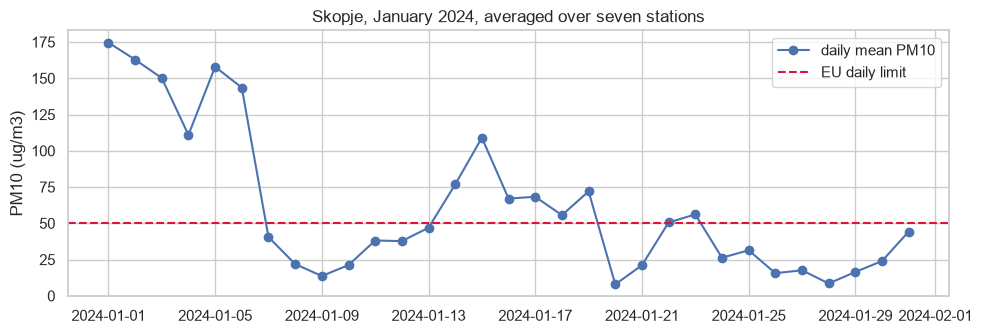

In [12]:
hourly = (
    readings.set_index("timestamp")
    .groupby("station_id")["pm10"]
    .resample("1h")
    .mean()
    .unstack(0)
)

city_hourly = hourly.mean(axis=1)
city_daily = city_hourly.resample("1D").mean()
days_over_limit = int((city_daily > PM10_DAILY_LIMIT).sum())

print("Hourly grid:", hourly.shape)
print(f"Mean PM10 across January: {city_hourly.mean():.2f}")
print(f"Days above the limit:     {days_over_limit} of {len(city_daily)}")

plt.figure(figsize=(10, 3.5))
plt.plot(city_daily.index, city_daily.to_numpy(), marker="o", label="daily mean PM10")
plt.axhline(PM10_DAILY_LIMIT, color="crimson", linestyle="--", label="EU daily limit")
plt.ylabel("PM10 (ug/m3)")
plt.title("Skopje, January 2024, averaged over seven stations")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
check(
    "days_over_limit" in dir()
    and days_over_limit == 14
    and "city_hourly" in dir()
    and abs(city_hourly.mean() - 60.92) < 0.5,
    "Task 6 complete. 14 days of 31 exceed the limit, and the mean is 60.92. "
    "Now go back and read your answer to Task 3 again.",
    "Not right yet. Expected 14 days above the limit and a mean near 60.92.",
)

Task 6 complete. 14 days of 31 exceed the limit, and the mean is 60.92. Now go back and read your answer to Task 3 again.


### Go Back And Look At Task 3

You have an answer. Fourteen days of January exceeded the European daily limit,
and the month averaged 60.92 micrograms per cubic metre. Every reading that
went into it survived a range check and a location check, and no value in the
series is missing.

Now recall the number you were told to set aside. Station 78456 reported a
median PM10 of 1.08 while the other seven stations reported between 8.50 and
60.63.

## Task 7: Measure What That Station Cost You

Station 78456 is not measuring Skopje's air. A working outdoor sensor in that
city in January does not report a median of 1.08 when every neighbour reports
eight to fifty-six times more. It is indoors, or filtered, or broken.
Which of the three does not matter, because none of them is the quantity you
are reporting.

Note what it survived. It has no missing values, it reported on all 31 days and
no station beats that, every reading is positive, and none is anywhere near the
sensor's ceiling. It fails no range check, no null check, and
no coordinate check. It is the tidiest column in the table.

Recompute the whole city series without it. Store the new count in
`honest_days_over_limit` and the new hourly series in `honest_hourly`, then
plot the two daily series together.

With station 78456:    mean  60.92, 14 days above the limit
Without station 78456: mean  71.40, 16 days above the limit

The reported mean was understated by 14.7 percent.


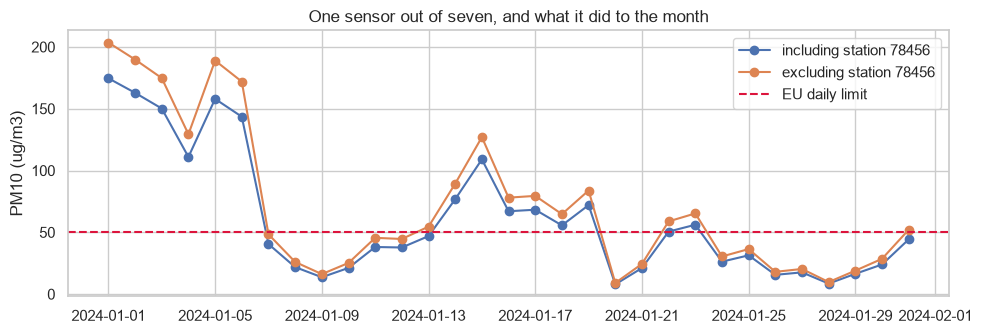

In [14]:
honest_hourly = hourly.drop(columns=[78456]).mean(axis=1)
honest_daily = honest_hourly.resample("1D").mean()
honest_days_over_limit = int((honest_daily > PM10_DAILY_LIMIT).sum())

print(f"With station 78456:    mean {city_hourly.mean():6.2f}, "
      f"{days_over_limit} days above the limit")
print(f"Without station 78456: mean {honest_hourly.mean():6.2f}, "
      f"{honest_days_over_limit} days above the limit")
print(f"\nThe reported mean was understated by "
      f"{(1 - city_hourly.mean() / honest_hourly.mean()) * 100:.1f} percent.")

plt.figure(figsize=(10, 3.5))
plt.plot(city_daily.index, city_daily.to_numpy(), marker="o",
         label="including station 78456")
plt.plot(honest_daily.index, honest_daily.to_numpy(), marker="o",
         label="excluding station 78456")
plt.axhline(PM10_DAILY_LIMIT, color="crimson", linestyle="--", label="EU daily limit")
plt.ylabel("PM10 (ug/m3)")
plt.title("One sensor out of seven, and what it did to the month")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
check(
    "honest_days_over_limit" in dir()
    and honest_days_over_limit == 16
    and "honest_hourly" in dir()
    and abs(honest_hourly.mean() - 71.40) < 0.5,
    "Task 7 complete. 16 days exceeded the limit, not 14, and the mean is 71.40.",
    "Not right yet. Expected 16 days above the limit and a mean near 71.40.",
)

Task 7 complete. 16 days exceeded the limit, not 14, and the mean is 71.40.


### What Just Happened

One sensor in seven, contributing a seventh of most hourly averages, pulled the
month's mean down from 71.40 to 60.92 and hid two days of exceedance. Reported
as it stood, the answer understates Skopje's January by just under fifteen
percent and undercounts the days on which a legal limit was breached.

Nothing in the modelling was wrong, because there was no modelling. The whole
error was committed during data preparation, and it was committed in Task 3, at
the moment you saw the median of 1.08 and moved on.

The general shape of this is worth carrying. Task 5's defect was caught by a
rule, because a station in Belgium violates a fact about geography that can be
written down. Task 7's defect violates no rule at all. It was found by
comparing a sensor against its neighbours, which is the only check that would
have found it, and that check exists only if somebody thinks to make it.

Averaging is what made it dangerous. A mean across seven stations gives a
broken one a full seventh of the answer and reports no sign of distress. Look
at the parts before you combine them, because the combination is where evidence
goes to disappear.

## Task 8: Save The Dataset

The point of a day spent preparing data is the dataset at the end of it. Write
`honest_hourly` out as a two-column CSV of `timestamp` and `pm10`, into
`DATA_DIR / "city_hourly_pm10.csv"`.

It is an hourly, regularly spaced, single-valued series covering January 2024,
which is the shape any time series method expects and none of the eight
original files had.

In [16]:
output = honest_hourly.rename("pm10").to_frame()
output.index.name = "timestamp"
output.to_csv(DATA_DIR / "city_hourly_pm10.csv")

print("Rows written:", len(output))
print("Missing values:", int(output["pm10"].isna().sum()))
print("Spacing is regular:", output.index.to_series().diff().dropna().nunique() == 1)
output.head()

Rows written: 744
Missing values: 0


Spacing is regular: True


,pm10
timestamp,
2024-01-01 00:00:00+00:00,197.384947
2024-01-01 01:00:00+00:00,225.577519
2024-01-01 02:00:00+00:00,232.917756
2024-01-01 03:00:00+00:00,211.285736
2024-01-01 04:00:00+00:00,192.880517


## Extensions

Each of these is worked through below.

1. The mean across stations gives every station an equal vote in every hour,
   but station 78188 reported on only 24 days. Work out which hours are
   averaged over fewer stations than others, and decide whether that changes
   the answer to Task 7.
2. Use the median across stations instead of the mean, without removing station
   78456. Does the median resist one broken sensor in seven well enough to
   recover the right answer on its own?
3. Write a function that flags a station whose readings correlate poorly with
   the rest of the network over the same hours. Check whether it would have
   found station 78456 without anybody looking at the table.
4. PM2.5 was carried through the whole laboratory exercise and never used.
   Compute the ratio of PM2.5 to PM10 per station and see whether station 78456
   stands out there too.
5. Resample to a daily mean directly from the raw readings, without the
   intermediate hourly step, and explain why the two answers differ.

### Extension 1: The Hours That Are Averaged Over Fewer Stations

`mean(axis=1)` averages whatever is present in an hour and says nothing about
how many that was. Count the stations behind each hourly average first, then
recompute the month using only the stations that were never absent, and see
whether the answer to Task 7 depends on the difference.

Hours by the number of stations averaged:
4      1
5    220
6    523

Days on which at least one station is absent for the whole day:
station_id                 20701  34617  60237  61184  78188  81853
timestamp                                                          
2024-01-05 00:00:00+00:00     24     24     24     24      0     24
2024-01-06 00:00:00+00:00     24     24     24     24      0     24
2024-01-07 00:00:00+00:00     24     24     24     24      0     24
2024-01-08 00:00:00+00:00     24     24     24     24      0     24
2024-01-09 00:00:00+00:00     24     24     24     24      0     24
2024-01-10 00:00:00+00:00     24     24     24     24      0     24
2024-01-11 00:00:00+00:00     24     24     24     24      0     24
2024-01-30 00:00:00+00:00     24     24     24     24     24      0

Stations present on every day: [20701, 34617, 60237, 61184]
All six stations:      mean  71.40, 16 days above the limit.
Only those four:       mean  67.62, 16 days above the limit.
The

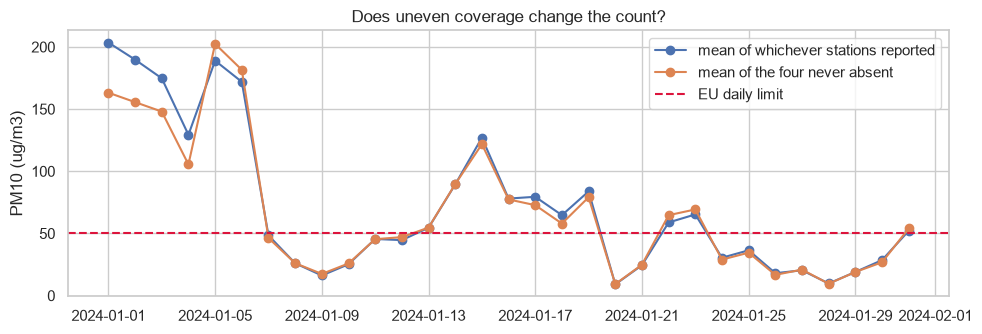

In [17]:
six_station = hourly.drop(columns=[78456])
coverage = six_station.notna().sum(axis=1)

print("Hours by the number of stations averaged:")
print(coverage.value_counts().sort_index().rename("hours").to_string())

per_day = six_station.notna().resample("1D").sum()
absent = per_day[(per_day == 0).any(axis=1)]
print("\nDays on which at least one station is absent for the whole day:")
print(absent.to_string())

always_on = per_day.columns[(per_day > 0).all()].tolist()
core_hourly = six_station[always_on].mean(axis=1)
core_daily = core_hourly.resample("1D").mean()
core_days_over_limit = int((core_daily > PM10_DAILY_LIMIT).sum())

print(f"\nStations present on every day: {always_on}")
print(f"All six stations:      mean {honest_hourly.mean():6.2f}, "
      f"{honest_days_over_limit} days above the limit.")
print(f"Only those four:       mean {core_hourly.mean():6.2f}, "
      f"{core_days_over_limit} days above the limit.")
print("The same days exceed in both:",
      set(honest_daily[honest_daily > PM10_DAILY_LIMIT].index)
      == set(core_daily[core_daily > PM10_DAILY_LIMIT].index))

near_limit = pd.DataFrame({"six stations": honest_daily, "four stations": core_daily})
print("\nThe days that come closest to deciding the count:")
print(near_limit[(near_limit - PM10_DAILY_LIMIT).abs().min(axis=1) < 10].round(2).to_string())

plt.figure(figsize=(10, 3.5))
plt.plot(honest_daily.index, honest_daily.to_numpy(), marker="o",
         label="mean of whichever stations reported")
plt.plot(core_daily.index, core_daily.to_numpy(), marker="o",
         label="mean of the four never absent")
plt.axhline(PM10_DAILY_LIMIT, color="crimson", linestyle="--", label="EU daily limit")
plt.ylabel("PM10 (ug/m3)")
plt.title("Does uneven coverage change the count?")
plt.legend()
plt.tight_layout()
plt.show()

Coverage is uneven in 221 of the 744 hours, where five stations are averaged
rather than six, and one hour rests on four. Station 78188 is absent for the
whole of the fifth to the eleventh of January and station 81853 for the whole
of the thirtieth, so the gaps are long stretches rather than scattered holes,
and the shorter gaps sit at the edges of those outages and on the last day of
the month.

The count survives it. Averaging only the four stations that reported on every
day of the month gives 16 days above the limit, exactly the same 16 days, while
the mean falls from 71.40 to 67.62. That drop is worth reading as a warning
rather than as a correction, because neither figure is more correct than the
other. Four stations describe the city less well than six do, and six stations
describe it unevenly across the month. What the agreement shows is only that
the conclusion of Task 7 does not rest on the choice.

Five days sit within six micrograms of the limit, so the count turns on them.
The seventh of January reads 48.38 over six stations and 46.32 over four, the
eleventh 45.53 and 45.38, and the twelfth 44.62 and 47.02, all of them below
the limit either way, while the thirteenth reads 54.57 and 54.69 and the
thirty-first 52.13 and 54.05, both above it either way. Changing which stations
are averaged moves those days by up to two and a half micrograms, which is the
size of the margin by which the closest of them misses. The answer is stable
against this particular disturbance and it is not comfortable, which is a
distinction worth reporting to whoever receives the number.

### Extension 2: Does The Median Across Stations Rescue The Answer?

The median is the standard advice for a summary that one bad value cannot
capture. Station 78456 is one bad value out of seven, so this is exactly the
situation the advice is meant for. Compute the city series with `median(axis=1)`
instead of `mean(axis=1)`, leaving the broken station in, and compare it against
both of the answers already in hand.

statistic      stations  mean_pm10  days_over_limit
     mean     all seven      60.92               14
     mean 78456 removed      71.40               16
   median     all seven      53.03               12
   median 78456 removed      58.85               15

The seven station readings for one hour, in order:
station_id
78456      1.11
81853     66.11
34617     82.60
20701    110.35
61184    123.72
78188    179.39
60237    181.01
Median of seven is the fourth value, 110.35, and of the six honest ones the average of the third and fourth, 117.03.


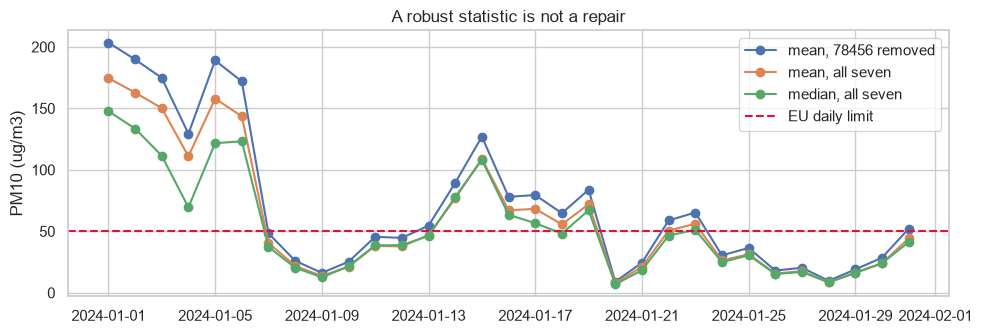

In [18]:
median_hourly = hourly.median(axis=1)
median_daily = median_hourly.resample("1D").mean()
median_days = int((median_daily > PM10_DAILY_LIMIT).sum())

median_honest_hourly = hourly.drop(columns=[78456]).median(axis=1)
median_honest_daily = median_honest_hourly.resample("1D").mean()
median_honest_days = int((median_honest_daily > PM10_DAILY_LIMIT).sum())

summary = pd.DataFrame(
    [
        ("mean", "all seven", city_hourly.mean(), days_over_limit),
        ("mean", "78456 removed", honest_hourly.mean(), honest_days_over_limit),
        ("median", "all seven", median_hourly.mean(), median_days),
        ("median", "78456 removed", median_honest_hourly.mean(), median_honest_days),
    ],
    columns=["statistic", "stations", "mean_pm10", "days_over_limit"],
)
print(summary.round(2).to_string(index=False))

one_hour = hourly.loc["2024-01-15 08:00:00+00:00"].sort_values()
print("\nThe seven station readings for one hour, in order:")
print(one_hour.round(2).to_string())
print(f"Median of seven is the fourth value, {one_hour.iloc[3]:.2f}, and of the "
      f"six honest ones the average of the third and fourth, "
      f"{one_hour.iloc[3:5].mean():.2f}.")

plt.figure(figsize=(10, 3.5))
plt.plot(honest_daily.index, honest_daily.to_numpy(), marker="o",
         label="mean, 78456 removed")
plt.plot(city_daily.index, city_daily.to_numpy(), marker="o",
         label="mean, all seven")
plt.plot(median_daily.index, median_daily.to_numpy(), marker="o",
         label="median, all seven")
plt.axhline(PM10_DAILY_LIMIT, color="crimson", linestyle="--", label="EU daily limit")
plt.ylabel("PM10 (ug/m3)")
plt.title("A robust statistic is not a repair")
plt.legend()
plt.tight_layout()
plt.show()

The median does not rescue it, and it does worse than the mean did. Taken over
all seven stations the median reports a monthly average of 53.03 and 12 days
above the limit, against the mean's 60.92 and 14 days, where the answer with
the broken station removed is 71.40 and 16 days.

The reason is visible in the single hour printed above. The median of seven
values is the fourth of them in order, and station 78456 always sits at the
bottom of that order, so it does not have to be extreme to do damage. It only
has to occupy a place in the ranking, which pushes the median down by one
position for every hour of the month. A robust statistic resists a value that
is wildly wrong, and this one is not wildly wrong in the sense the median cares
about, it is merely always last.

The final row is the subtler warning. With station 78456 removed, the median
still reports 58.85 and 15 days, well below the mean's 71.40 and 16. That gap
is not error, because the seven stations differ genuinely and their hourly
readings are skewed to the right, so the median of them is a smaller quantity
than the mean of them. Switching statistic changes what is being reported as
well as how it resists a bad input, and the European limit is written about a
mean. Choosing the median here would answer a different question quietly.

### Extension 3: A Check That Compares Each Station Against Its Neighbours

Station 78456 was found by eye, which does not scale and does not survive the
next month's data. The property that gave it away is that its readings do not
move with everybody else's, and that property can be measured. Correlate each
station's hourly series against the mean of the others over the hours they
share, and flag anything that fails to follow the network.

In [19]:
def flag_by_correlation(grid, threshold=0.6, min_hours=100):
    """Score each station against the mean of the others over their shared hours."""
    rows = []
    for station in grid.columns:
        others = grid.drop(columns=[station]).mean(axis=1)
        paired = pd.concat([grid[station], others], axis=1).dropna()
        correlation = paired.iloc[:, 0].corr(paired.iloc[:, 1])
        rows.append(
            {
                "station_id": station,
                "hours_compared": len(paired),
                "correlation": correlation,
                # A station with too little overlap is unjudged rather than cleared.
                "flagged": len(paired) >= min_hours and correlation < threshold,
            }
        )
    return pd.DataFrame(rows).set_index("station_id").sort_values("correlation")


print("The seven stations that reached Task 6:")
print(flag_by_correlation(hourly).round(3).to_string())

# The same check run before Task 5, on all eight stations as they arrived.
raw = pd.concat(frames, ignore_index=True)
raw["timestamp"] = pd.to_datetime(raw["timestamp"], format="mixed", utc=True)
raw.loc[raw["pm10"] >= 1999.9, "pm10"] = np.nan
hourly_eight = (
    raw.set_index("timestamp")
    .groupby("station_id")["pm10"]
    .resample("1h")
    .mean()
    .unstack(0)
)

print("\nAll eight stations, before the mislocated one was removed:")
print(flag_by_correlation(hourly_eight).round(3).to_string())

The seven stations that reached Task 6:
            hours_compared  correlation  flagged
station_id                                      
78456                  744        0.470     True
60237                  737        0.746    False
20701                  744        0.792    False
81853                  712        0.860    False
78188                  561        0.881    False
34617                  744        0.887    False
61184                  744        0.928    False



All eight stations, before the mislocated one was removed:
            hours_compared  correlation  flagged
station_id                                      
78844                  744       -0.190     True
78456                  744        0.464     True
60237                  737        0.738    False
20701                  744        0.793    False
81853                  712        0.858    False
78188                  561        0.880    False
34617                  744        0.886    False
61184                  744        0.928    False


The check finds it. Station 78456 correlates with the rest of the network at
0.46 while the other six run from 0.75 to 0.93, and it is the only station the
rule flags. Nothing about its own column had to be inspected, and no threshold
on a plausible concentration was needed, because the quantity being tested is
agreement rather than magnitude.

Run on all eight stations as they arrived, the check also flags the station
that Task 5 caught, and more decisively. Station 78844 correlates at minus
0.19, since air 1600 kilometres away shares nothing with Skopje's weather, so
the same rule catches both defects while the coordinate rule catches only one.
That is worth noticing before trusting it too far. A sensor sitting a street
away from a neighbour would still correlate well while reading twice as high,
so this check tests the shape of a series and not its level, and a station that
is merely mis-scaled would pass it.

Two details of the function matter more than the threshold. It compares each
station against the mean of the others rather than against the full network
mean, since a station included in the thing it is measured against inflates its
own score. And a station with too little overlap is reported unjudged rather
than cleared, because a correlation over a handful of hours is noise. Station
78188 shows why the second rule is needed and also that it is not sufficient:
it is missing for a week, and still correlates at 0.88 over the 561 hours it
does report, so absence and brokenness are different faults.

### Extension 4: What PM2.5 Says About The Same Station

`pm25` has been carried through every task without being used. PM2.5 counts the
smaller particles, which are a subset of what PM10 counts, so the ratio of the
two is a property of the mix of particles in the air rather than of how dirty
it is. Stations in one city breathing the same air should agree on it more
closely than they agree on concentration.

            median_pm10  median_pm25  median_ratio
station_id                                        
20701            45.065        26.13         0.591
34617            30.550        19.00         0.627
60237            60.530        34.08         0.626
61184            34.600        15.48         0.436
78188            60.630        31.15         0.489
78456             1.080         0.25         0.222
81853            37.100        20.40         0.551

Station 78456 ratio:      0.222
The other six range over: 0.436 to 0.627


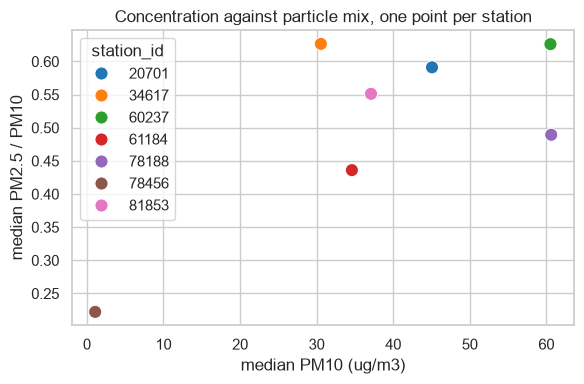

In [20]:
ratios = readings.assign(ratio=readings["pm25"] / readings["pm10"])
by_station = ratios.groupby("station_id").agg(
    median_pm10=("pm10", "median"),
    median_pm25=("pm25", "median"),
    median_ratio=("ratio", "median"),
)
print(by_station.round(3).to_string())

others = by_station.drop(index=78456)
print(f"\nStation 78456 ratio:      {by_station.loc[78456, 'median_ratio']:.3f}")
print(f"The other six range over: {others['median_ratio'].min():.3f} to "
      f"{others['median_ratio'].max():.3f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=by_station.reset_index(), x="median_pm10", y="median_ratio",
                hue="station_id", palette="tab10", s=90, legend="full")
plt.xlabel("median PM10 (ug/m3)")
plt.ylabel("median PM2.5 / PM10")
plt.title("Concentration against particle mix, one point per station")
plt.tight_layout()
plt.show()

It stands out here too, and on a quantity that has nothing to do with how dirty
the air is. Station 78456 reports a median PM2.5 to PM10 ratio of 0.222 while
the other six lie between 0.436 and 0.627, so it is outside their range rather
than at the edge of it.

That is a second, independent piece of evidence, and it rules out the most
innocent explanation available. A sensor whose calibration is simply wrong by a
constant factor would report both pollutants too low in the same proportion,
and the ratio would come out unchanged. This one reports a different mixture,
which is what a sensor breathing filtered or indoor air would do, since
filtration and settling remove the coarse fraction that separates PM10 from
PM2.5.

Note what the scatter does not show. The six honest stations differ by a factor
of two in concentration while their ratios do not order with it, which is the
point, since the ratio is a property they share and the concentration is not.
A check built on a quantity that ought to be constant across sources is
usually easier to set a threshold on than one built on the quantity being
measured.

### Extension 5: Resampling Straight To Days

The hourly grid looks like an extra step, since `resample("1D")` would accept
the raw readings directly. Take the daily mean both ways and compare them day
by day.

In [21]:
direct_daily = (
    readings[readings["station_id"] != 78456]
    .set_index("timestamp")["pm10"]
    .resample("1D")
    .mean()
)

comparison = pd.DataFrame({"via hourly": honest_daily, "direct": direct_daily})
comparison["difference"] = comparison["direct"] - comparison["via hourly"]
print(f"Via the hourly grid: mean {honest_daily.mean():6.2f}, "
      f"{int((honest_daily > PM10_DAILY_LIMIT).sum())} days above the limit.")
print(f"Straight to days:    mean {direct_daily.mean():6.2f}, "
      f"{int((direct_daily > PM10_DAILY_LIMIT).sum())} days above the limit.")
print("\nThe five days that differ most:")
print(comparison.reindex(comparison["difference"].abs().sort_values(ascending=False).index)
      .head(5).round(2).to_string())

worst_day = comparison["difference"].abs().idxmax()
hours_of_worst = (
    readings[(readings["station_id"] != 78456)
             & (readings["timestamp"] >= worst_day)
             & (readings["timestamp"] < worst_day + pd.Timedelta(days=1))]
    .set_index("timestamp")["pm10"]
    .resample("1h")
    .agg(["count", "mean"])
)
print(f"\nEvery hour of {worst_day.date()}, which differs most:")
print(hours_of_worst.round(2).to_string())
print(f"\nCorrelation between an hour's reading count and its mean PM10: "
      f"{hours_of_worst['count'].corr(hours_of_worst['mean']):.2f}")

Via the hourly grid: mean  71.40, 16 days above the limit.
Straight to days:    mean  71.93, 16 days above the limit.

The five days that differ most:
                           via hourly  direct  difference
timestamp                                                
2024-01-02 00:00:00+00:00      189.78  197.32        7.54
2024-01-05 00:00:00+00:00      188.95  186.87       -2.08
2024-01-16 00:00:00+00:00       78.04   79.89        1.85
2024-01-31 00:00:00+00:00       52.13   53.93        1.81
2024-01-13 00:00:00+00:00       54.57   55.52        0.95

Every hour of 2024-01-02, which differs most:
                           count    mean
timestamp                               
2024-01-02 00:00:00+00:00    147  241.43
2024-01-02 01:00:00+00:00    145  255.27
2024-01-02 02:00:00+00:00    147  234.08
2024-01-02 03:00:00+00:00    146  225.66
2024-01-02 04:00:00+00:00    146  231.58
2024-01-02 05:00:00+00:00    148  238.48
2024-01-02 06:00:00+00:00    146  236.20
2024-01-02 07:00:00+00:00  

Both routes give 16 days above the limit, and the monthly means differ by half
a microgram, 71.93 against 71.40. The day by day differences are larger, up to
7.54 on the second of January, and four of the five largest run in the same
direction, with the direct mean reporting the dirtier day.

The mechanism is what each route gives equal weight to. Averaging the raw rows
weights every reading equally, so an hour that produced more readings counts for
more of the day, and a station that reports more often counts for more than one
that reports less often. Averaging the hourly grid weights every hour equally
and, within an hour, every station equally, which is the quantity a daily limit
is actually written about.

The second of January shows it plainly. The readings thin out from the tenth
hour to the eighteenth, falling to as few as 69 in an hour against about 147
overnight, and those are precisely the hours when the air was cleanest, at
around 76 to 175 micrograms against 220 or more at night. Count and
concentration correlate at 0.51 over that day. The cleanest hours brought the
fewest readings, the direct mean therefore heard less of them, and the day came
out 7.54 micrograms dirtier than it was.

The two answers agree here because the effect is small next to the distance
between most days and the limit. That agreement is a fact about this month
rather than a reason to skip the grid. Irregular sampling that correlates with
the quantity being measured is exactly the case in which the shortcut fails,
and a sensor that drops readings when it is busy or cold produces that
correlation for free.

## What To Take Away

- Look at every source separately before you combine them. An average across
  sensors is exactly the operation that conceals a broken sensor.
- A column with no missing values, no outliers, and complete coverage can still
  be entirely wrong. Tidiness is not correctness.
- Parse timestamps to a single explicit timezone. A mixed column parses into
  `object` dtype without raising, and fails later somewhere unrelated.
- A repeated value at the top of an instrument's range is the instrument
  refusing to answer, not a measurement.
- Treat metadata as data and check it. Coordinates, identifiers, and units all
  arrive wrong sometimes.
- Say which way an unavoidable error runs. Both available treatments of the
  saturated readings bias the month downward, and the reader needs to know
  that.
- Write the decisions down. Every repair in this laboratory exercise changed
  the published answer, and none of them left a trace in the output.